<a href="https://colab.research.google.com/github/26wh5a0538-create/NASSCOM/blob/main/Loading_Datasets_from_Multiple_Sources.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np

# 100k pairs of coin flips (0 = Tail, 1 = Head)
flips = np.random.randint(0, 2, size=(100_000, 2))

# Number of heads in each pair: 0, 1, or 2
heads = flips.sum(axis=1)

# 1. P(both heads) -> heads == 2
p_both_heads = np.mean(heads == 2)
print("P(both heads) =", p_both_heads)


P(both heads) = 0.24807


In [7]:
p_at_least_one_head = np.mean(heads >= 1)
print("P(at least one head) =", p_at_least_one_head)

P(at least one head) = 0.74975


In [8]:
p0 = np.mean(heads == 0)
p1 = np.mean(heads == 1)
p2 = np.mean(heads == 2)

print("Sum =", p0 + p1 + p2)

Sum = 1.0


In [11]:


rolls = np.random.randint(1, 7, size=100_000)

even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')



P(6 | even) ~ 0.336  (true 1/3)


In [13]:
-
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))


P(A)      = 0.502
P(A | B)  = 0.667
Independent? False


In [15]:
import numpy as np

rolls = np.random.randint(1, 7, size=100_000)

less_than_4 = rolls[rolls < 4]      # {1, 2, 3}
p_odd_given_lt4 = (less_than_4 % 2 == 1).mean()


p_lt4 = (rolls < 4).mean()


p_odd = (rolls % 2 == 1).mean()

print("P(odd | roll < 4) =", p_odd_given_lt4)
print("P(roll < 4) =", p_lt4)
print("P(odd) =", p_odd)

if np.isclose(p_odd_given_lt4, p_odd, atol=0.01):
    print("Odd and (roll < 4) are approximately independent.")
else:
    print("Odd and (roll < 4) are not independent.")

P(odd | roll < 4) = 0.6667462449020193
P(roll < 4) = 0.50265
P(odd) = 0.50034
Odd and (roll < 4) are not independent.


In [16]:



p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [17]:


N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.493


Sample mean: 1.994


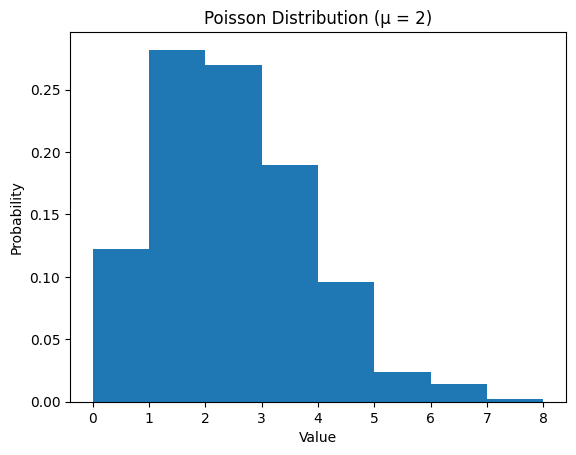

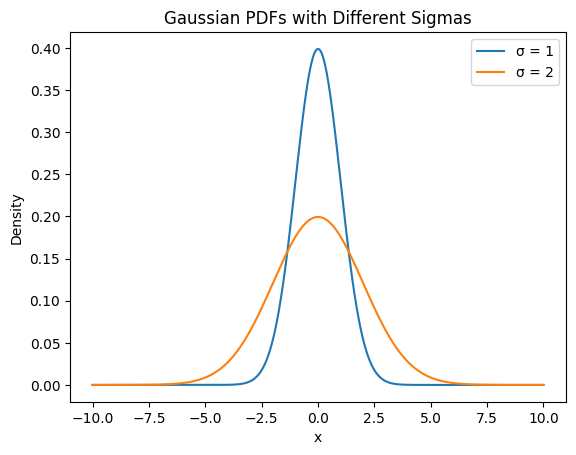

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Poisson(mu=2) samples + mean
samples = np.random.poisson(lam=2, size=1000)
print("Sample mean:", np.mean(samples))

# 2. histogram of the samples (plt.hist(...))
plt.hist(samples, bins=range(samples.max() + 2), density=True)
plt.title("Poisson Distribution (μ = 2)")
plt.xlabel("Value")
plt.ylabel("Probability")
plt.show()

# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-10, 10, 1000)

pdf_sigma1 = norm.pdf(x, loc=0, scale=1)
pdf_sigma2 = norm.pdf(x, loc=0, scale=2)

plt.plot(x, pdf_sigma1, label="σ = 1")
plt.plot(x, pdf_sigma2, label="σ = 2")

plt.title("Gaussian PDFs with Different Sigmas")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

In [21]:


from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')



Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [22]:


P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')



D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [23]:


from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')


0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [24]:
from scipy.stats import entropy
import numpy as np

# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)

die4 = np.ones(4) / 4
die6 = np.ones(6) / 6

entropy_4 = entropy(die4, base=2)
entropy_6 = entropy(die6, base=2)

print("Entropy of fair 4-sided die:", entropy_4)
print("Entropy of fair 6-sided die:", entropy_6)

# 2. KL divergence D(P || Q)

P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

kl_div = entropy(P, Q, base=2)

print("KL Divergence D(P || Q):", kl_div)

# 3. Most / least informative iris feature (from 5C)

print("Most informative: petal length (cm)")
print("Least informative: sepal width (cm)")

Entropy of fair 4-sided die: 2.0
Entropy of fair 6-sided die: 2.584962500721156
KL Divergence D(P || Q): 0.11870910076930725
Most informative: petal length (cm)
Least informative: sepal width (cm)
